# Solution: Generating Images with Reverse Diffusion

This notebook contains the complete solution for implementing reverse diffusion sampling.

## Key Concepts Covered:
- Reconstructing the noise schedule from training
- Implementing the DDPM reverse sampling algorithm
- Understanding the denoising formula and posterior variance

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(" Imports complete")

Using device: cuda
 Imports complete


## Model Architecture Definitions

In [2]:
class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding for timestep conditioning."""

    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timestep):
        device = timestep.device
        half_dim = self.embedding_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / half_dim
        )
        args = timestep[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResidualBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels, out_channels, time_embedding_dim=128):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups=32, num_channels=out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embedding_dim, out_channels),
            nn.SiLU(),
            nn.Linear(out_channels, out_channels),
        )
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, time_embedding):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)
        time_scale_shift = self.time_mlp(time_embedding)[:, :, None, None]
        h = h * time_scale_shift
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)


class SimpleUNet(nn.Module):
    """Simple U-Net for MNIST noise prediction."""

    def __init__(self, image_channels=1, base_channels=64, time_embedding_dim=128):
        super().__init__()
        self.time_embedding = TimeEmbedding(time_embedding_dim)
        self.init_conv = nn.Conv2d(
            image_channels, base_channels, kernel_size=3, padding=1
        )

        # Encoder
        self.down_conv1 = nn.Conv2d(
            base_channels, base_channels, kernel_size=4, stride=2, padding=1
        )
        self.down_res1 = ResidualBlock(
            base_channels, base_channels * 2, time_embedding_dim
        )

        self.down_conv2 = nn.Conv2d(
            base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1
        )
        self.down_res2 = ResidualBlock(
            base_channels * 2, base_channels * 2, time_embedding_dim
        )

        # Middle
        self.middle_res = ResidualBlock(
            base_channels * 2, base_channels * 2, time_embedding_dim
        )

        # Decoder
        self.up_conv2 = nn.ConvTranspose2d(
            base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1
        )
        self.up_res2 = ResidualBlock(
            base_channels * 2, base_channels, time_embedding_dim
        )

        self.up_conv1 = nn.ConvTranspose2d(
            base_channels, base_channels, kernel_size=4, stride=2, padding=1
        )
        self.up_res1 = ResidualBlock(base_channels, base_channels, time_embedding_dim)

        # Final output
        self.final_norm = nn.GroupNorm(num_groups=32, num_channels=base_channels)
        self.final_conv = nn.Conv2d(
            base_channels, image_channels, kernel_size=3, padding=1
        )

    def forward(self, x, timestep):
        time_emb = self.time_embedding(timestep)
        h = self.init_conv(x)

        h = self.down_conv1(h)
        h = self.down_res1(h, time_emb)

        h = self.down_conv2(h)
        h = self.down_res2(h, time_emb)

        h = self.middle_res(h, time_emb)

        h = self.up_conv2(h)
        h = self.up_res2(h, time_emb)

        h = self.up_conv1(h)
        h = self.up_res1(h, time_emb)

        h = self.final_norm(h)
        h = F.silu(h)
        h = self.final_conv(h)
        return h


print(" Model architecture defined")

 Model architecture defined


## Solution to TODO 1: Rebuild the Noise Schedule

The noise schedule defines how noise is added during the forward diffusion process. We must reconstruct it exactly as it was during training.

In [5]:
import warnings
warnings.filterwarnings("ignore")

# SOLUTION TO TODO 1: Rebuild the noise schedule
num_timesteps = 1000

# Step 1: Create linear beta schedule from 0.0001 to 0.02
# This creates 1000 evenly-spaced values between the two endpoints
betas = torch.linspace(0.0001, 0.02, num_timesteps)

# Step 2: Compute alphas (signal retention factors)
# alpha_t = 1 - beta_t represents how much signal is retained at each step
alphas = 1.0 - betas

# Step 3: Compute cumulative product of alphas
# This gives us ᾱ_t = ∏(α_i) from i=0 to t
# Tells us how much of the original signal remains after t steps
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Step 4: Create shifted version with leading 1.0
# This gives us ᾱ_{t-1} which we need for the posterior variance calculation
# [:-1] takes all elements except the last, prepending 1.0 for t=0
alphas_cumprod_prev = torch.cat([torch.ones(1), alphas_cumprod[:-1]])

# Verify the implementation
print(" Noise schedule successfully rebuilt")
print(f"  betas shape: {betas.shape}, range: [{betas.min():.4f}, {betas.max():.4f}]")
print(f"  alphas_cumprod shape: {alphas_cumprod.shape}")
print(f"  alphas_cumprod[0] = {alphas_cumprod[0]:.4f} (should be ~0.9999)")
print(f"  alphas_cumprod[-1] = {alphas_cumprod[-1]:.6f} (should be very small)")
print(f"  alphas_cumprod_prev[0] = {alphas_cumprod_prev[0]:.1f} (should be 1.0)")

 Noise schedule successfully rebuilt
  betas shape: torch.Size([1000]), range: [0.0001, 0.0200]
  alphas_cumprod shape: torch.Size([1000])
  alphas_cumprod[0] = 0.9999 (should be ~0.9999)
  alphas_cumprod[-1] = 0.000040 (should be very small)
  alphas_cumprod_prev[0] = 1.0 (should be 1.0)


## Load the Trained Model

In [11]:
# Load trained model
model = SimpleUNet(image_channels=1, base_channels=64, time_embedding_dim=128).to(device)

checkpoint_path = Path("../../../model_checkpoints/diffusion_model_lesson16.pt")
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

epochs_trained = checkpoint.get("epoch", "?")
print(f"✓ Loaded model trained for {epochs_trained} epochs")
print(f"  From: {checkpoint_path.resolve()}")


✓ Loaded model trained for 10 epochs
  From: /workspace/cd1823-building-genai/model_checkpoints/diffusion_model_lesson16.pt


## Solution to TODO 2: Implement DDPM Sampling

This is the heart of the reverse diffusion process. We start with pure noise and iteratively denoise it using the trained U-Net.

In [12]:
@torch.no_grad()
def sample_ddpm(model, num_samples=16):
    """
    Generate images via reverse diffusion: x_T → x_0.
    
    The denoising formula at each timestep is:
    x_{t-1} = (x_t - (1-α_t)/√(1-ᾱ_t) * ε_pred) / √α_t + √β̃_t * z
    
    Where:
    - ε_pred is the noise predicted by the U-Net
    - β̃_t is the posterior variance
    - z is random noise (only added when t > 0)
    """
    model.eval()
    
    # SOLUTION 2.1: Initialize x with pure Gaussian noise
    # Starting point for reverse diffusion - completely random noise
    x = torch.randn(num_samples, 1, 28, 28, device=device)
    
    # SOLUTION 2.2: Loop backward through timesteps
    # Go from t=999 down to t=0, progressively removing noise
    for t_idx in range(num_timesteps - 1, -1, -1):
        
        # Create timestep tensor for the entire batch
        # All samples in the batch are at the same timestep
        t = torch.full((num_samples,), t_idx, dtype=torch.long, device=device)
        
        # SOLUTION 2.3: Get noise prediction from the model
        # The U-Net predicts what noise was added to create x_t
        pred_noise = model(x, t)
        
        # SOLUTION 2.4: Get coefficients for this timestep
        # These are pre-computed values from our noise schedule
        alpha = alphas[t_idx]                    # Signal retention at this step
        alpha_cum = alphas_cumprod[t_idx]        # Cumulative signal retention
        alpha_cum_prev = alphas_cumprod_prev[t_idx]  # Previous cumulative value
        
        # SOLUTION 2.5: Compute posterior variance
        # β̃_t = (1 - ᾱ_{t-1}) / (1 - ᾱ_t) * β_t
        # This is the variance of q(x_{t-1} | x_t, x_0)
        # Remember: β_t = 1 - α_t
        posterior_var = (1 - alpha_cum_prev) / (1 - alpha_cum) * (1 - alpha)
        
        # SOLUTION 2.6: Apply denoising formula
        # This is the mean of the reverse process distribution
        # We're removing the predicted noise, scaled appropriately
        x = (x - (1 - alpha) / torch.sqrt(1 - alpha_cum) * pred_noise) / torch.sqrt(alpha)
        
        # SOLUTION 2.7: Add noise for all timesteps except the last (t=0)
        # This adds stochasticity to the reverse process
        # At t=0, we don't add noise because we want the final clean image
        if t_idx > 0:
            x = x + torch.sqrt(posterior_var) * torch.randn_like(x)
    
    # clamp final  output to valid image range [-1, 1]
    return torch.clamp(x, -1.0, 1.0)


print(" Sampling function defined with complete solution")


 Sampling function defined with complete solution


## Generate and Visualize Samples

Generating 16 samples (1000 reverse steps)... this may take a few minutes


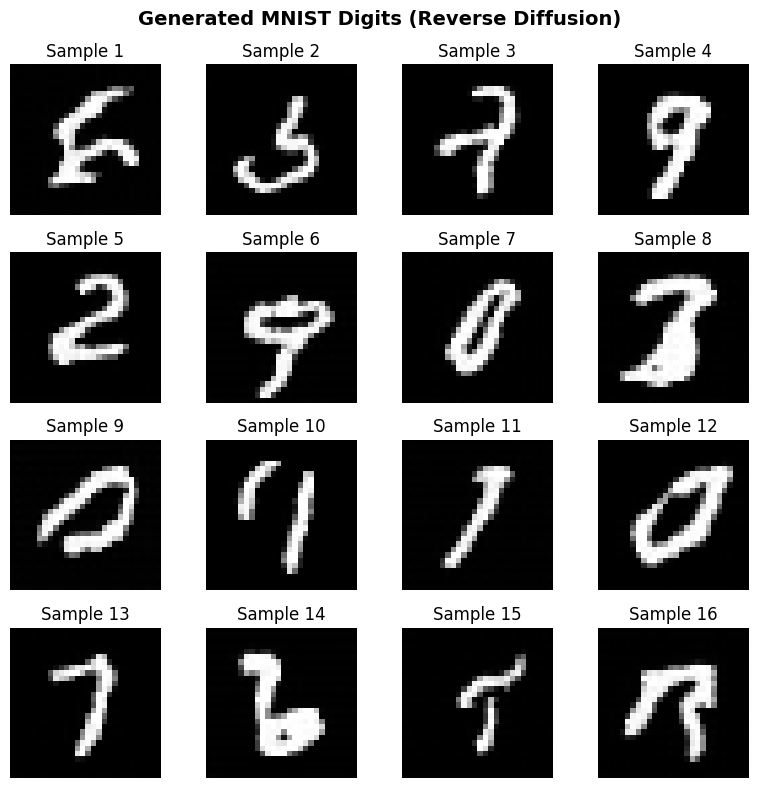

Sample range: [-1.000, 1.000]


In [13]:
print("Generating 16 samples (1000 reverse steps)... this may take a few minutes")
samples = sample_ddpm(model, num_samples=16)

# Visualize generated digits
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flat):
    ax.imshow(samples[idx, 0].cpu().numpy(), cmap="gray")
    ax.set_title(f"Sample {idx+1}")
    ax.axis("off")

plt.suptitle(
    "Generated MNIST Digits (Reverse Diffusion)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"Sample range: [{samples.min():.3f}, {samples.max():.3f}]")
